# 00 — Setup & Data Exploration

Este notebook cobre:
1. Carregamento do ArtBench-10 (Kaggle local ou HuggingFace)
2. Subset de 20% fornecido pelo professor (`training_20_percent.csv`)
3. Visualização de amostras por estilo artístico
4. `HFDatasetTorch` — classe reutilizada em todos os outros notebooks

> **Dataset**: 50 000 imagens de treino · 32×32 RGB · 10 estilos artísticos

In [1]:
from __future__ import annotations
import sys, random, csv
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# ── paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT   = Path('..').resolve()
SCRIPTS_DIR = REPO_ROOT / 'TP' / 'TP1-alunos-src-only' / 'scripts'
SUBSET_CSV  = REPO_ROOT / 'TP' / 'TP1-alunos-src-only' / 'student_start_pack' / 'training_20_percent.csv'
KAGGLE_ROOT = REPO_ROOT / 'data' / 'ArtBench-10'   # local Kaggle download (optional)

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── device ────────────────────────────────────────────────────────────────────
def get_device():
    if torch.cuda.is_available():              return torch.device('cuda')
    if torch.backends.mps.is_available():      return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print('Device:', device)

Device: mps


## 1. Carregar o dataset

In [2]:
from datasets import load_dataset, load_from_disk

DATA_CACHE = REPO_ROOT / 'data' / 'artbench10_hf'

if DATA_CACHE.exists():
    print(f'A carregar dataset do disco: {DATA_CACHE}')
    hf_ds = load_from_disk(str(DATA_CACHE))
else:
    print('A fazer download do dataset (primeira vez)...')
    hf_ds = load_dataset('zguo0525/ArtBench')
    DATA_CACHE.parent.mkdir(parents=True, exist_ok=True)
    hf_ds.save_to_disk(str(DATA_CACHE))
    print(f'Dataset guardado em: {DATA_CACHE}')

train_hf    = hf_ds['train']
class_names = list(train_hf.features['label'].names)
num_classes = len(class_names)

print('Train size :', len(train_hf))
print('Classes    :', class_names)

/Users/duartepereira/IAG/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


A fazer download do dataset (primeira vez)...


README.md:   0%|          | 0.00/721 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/418M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/408M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (0/4 shards):   0%|          | 0/50000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset guardado em: /Users/duartepereira/IAG/data/artbench10_hf
Train size : 50000
Classes    : ['expressionism', 'art_nouveau', 'renaissance', 'ukiyo_e', 'realism', 'romanticism', 'surrealism', 'impressionism', 'baroque', 'post_impressionism']


## 2. `HFDatasetTorch` — classe partilhada por todos os notebooks

Baseada no starter pack do professor. Aceita uma lista de índices para usar o subset de 20%.

In [3]:
IMAGE_SIZE  = 32
BATCH_SIZE  = 64
USE_SUBSET  = True   # False → dataset completo

def safe_num_workers():
    return 0 if 'ipykernel' in sys.modules else 2


class HFDatasetTorch(Dataset):
    """Wrapper HuggingFace → PyTorch, com suporte a subset por índices."""
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds        = hf_split
        self.transform = transform
        self.indices   = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):  return len(self.indices)

    def __getitem__(self, idx):
        ex  = self.ds[self.indices[idx]]
        img = ex['image']
        y   = int(ex['label'])
        x   = self.transform(img) if self.transform else img
        return x, y


def load_ids_from_csv(csv_path: Path, column: str = 'train_id_original') -> list[int]:
    """Lê os índices do subset de 20% fornecido pelo professor."""
    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        for row in csv.DictReader(f):
            v = str(row.get(column, '')).strip()
            if v:
                ids.append(int(v))
    print(f'Loaded {len(ids)} ids from {csv_path.name}')
    return ids


def build_loader(hf_split, transform, indices=None, shuffle=True):
    ds = HFDatasetTorch(hf_split, transform, indices)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=safe_num_workers(), pin_memory=torch.cuda.is_available())


# normalização para [-1, 1]  (usada nos modelos generativos)
transform_norm = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# normalização para [0, 1]   (usada na avaliação FID/KID)
transform_01 = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
])

# ── construir loader ──────────────────────────────────────────────────────────
subset_ids   = load_ids_from_csv(SUBSET_CSV) if USE_SUBSET else None
train_loader = build_loader(train_hf, transform_norm, indices=subset_ids)

print(f'Amostras de treino : {len(train_loader.dataset)}')
print(f'Batches            : {len(train_loader)}')

Loaded 10000 ids from training_20_percent.csv
Amostras de treino : 10000
Batches            : 157


## 3. Distribuição de classes

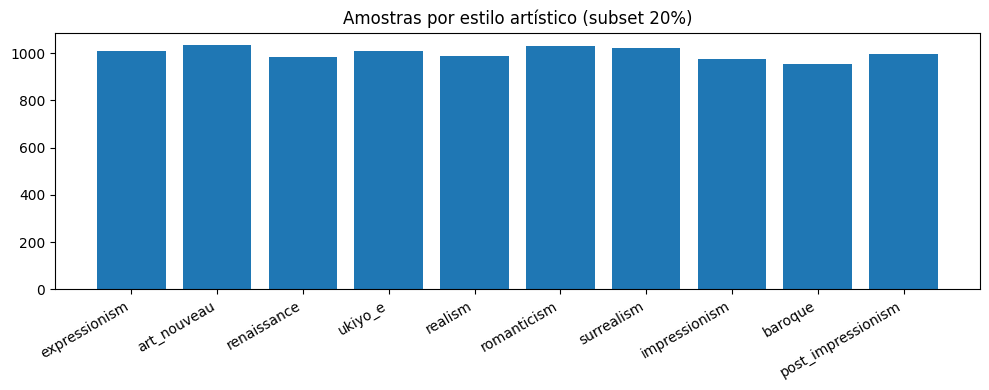

In [4]:
labels = [train_hf[i]['label'] for i in (subset_ids if USE_SUBSET else range(len(train_hf)))]
counts = Counter(labels)

plt.figure(figsize=(10, 4))
plt.bar([class_names[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)])
plt.xticks(rotation=30, ha='right')
plt.title('Amostras por estilo artístico' + (' (subset 20%)' if USE_SUBSET else ' (full)'))
plt.tight_layout()
plt.show()

## 4. Grelha de amostras

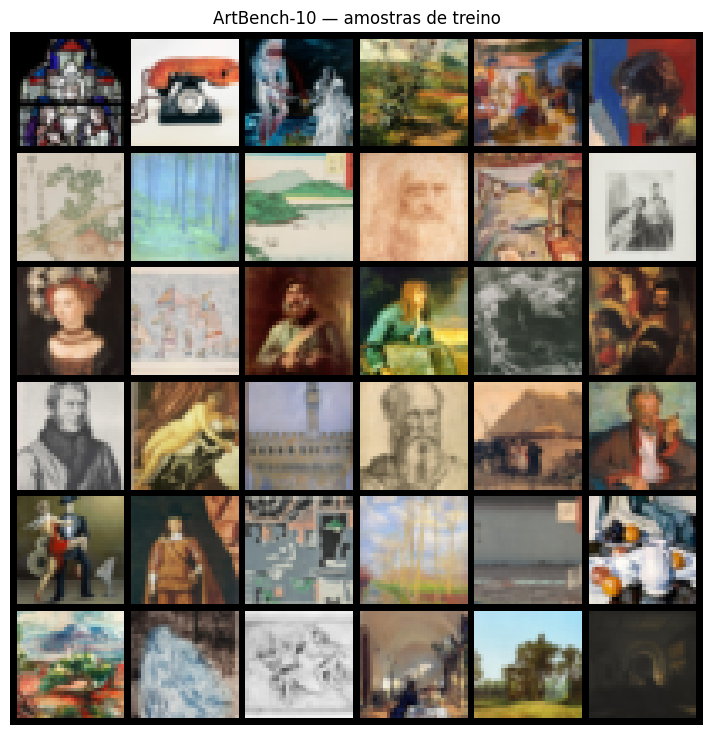

Labels: ['romanticism', 'surrealism', 'surrealism', 'post_impressionism', 'impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'ukiyo_e', 'renaissance', 'post_impressionism', 'romanticism', 'renaissance', 'surrealism', 'realism', 'realism', 'expressionism', 'baroque', 'romanticism', 'baroque', 'expressionism', 'renaissance', 'realism', 'impressionism', 'surrealism', 'baroque', 'expressionism', 'post_impressionism', 'ukiyo_e', 'post_impressionism', 'impressionism', 'expressionism', 'renaissance', 'impressionism', 'romanticism', 'baroque']


In [5]:
x_batch, y_batch = next(iter(train_loader))
# denormalizar [-1,1] → [0,1]
x_show = (x_batch[:36] * 0.5 + 0.5).clamp(0, 1)

grid   = make_grid(x_show, nrow=6, padding=2)
plt.figure(figsize=(9, 9))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title('ArtBench-10 — amostras de treino')
plt.axis('off')
plt.show()

print('Labels:', [class_names[y] for y in y_batch[:36].tolist()])

## 5. Verificação de shape

In [ ]:
print('Batch shape :', x_batch.shape)       # (64, 3, 32, 32)
print('Pixel range :', x_batch.min().item(), '→', x_batch.max().item())  # [-1, 1]
print('Num classes :', num_classes)
print('Classes     :', class_names)

Batch shape : torch.Size([64, 3, 32, 32])
Pixel range : -1.0 → 0.9921568632125854
Num classes : 10
Classes     : ['expressionism', 'art_nouveau', 'renaissance', 'ukiyo_e', 'realism', 'romanticism', 'surrealism', 'impressionism', 'baroque', 'post_impressionism']


: 